# História completa — perfis epidemiológicos de dengue no Nordeste

**Trabalho:** Inteligência Artificial IV · aprendizado **não supervisionado**

**Pergunta central:** quais perfis epidemiológicos emergem ao combinar incidência, tendência temporal e contexto municipal, e como municípios transitam entre esses perfis ao longo das semanas?

**Unidade de análise:** município × semana epidemiológica (9 estados do Nordeste).

**Roteiro deste notebook:**
1. Dados e pipeline
2. Baseline v0 (limitação)
3. Escada de features v0→v4
4. Escolha de K no modelo final
5. Interpretação dos clusters
6. Transições semanais
7. Estabilidade em 10 anos
8. Conclusão


In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

_cwd = Path.cwd().resolve()
if (_cwd / "ml").is_dir():
    ROOT = _cwd
elif (_cwd.parent / "ml").is_dir():
    ROOT = _cwd.parent
else:
    raise RuntimeError("Abra o notebook a partir de ia-iv/ ou ia-iv/notebooks/.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for name in list(sys.modules):
    if name == "ml" or name.startswith("ml."):
        del sys.modules[name]

from ml.cluster import run_kmeans
from ml.columns import Col, Feat, FEATURE_SETS
from ml.config import DEFAULT_K, DEFAULT_MIN_CASOS_ANUAL, DEFAULT_YEARS, REFERENCE_POP_YEAR
from ml.dataset import build_features_panel, load_region_raw
from ml.experiments import load_experiments
from ml.paths import region_manifest_path
from ml.preprocess import build_region_parquet
from ml.regions import NE
from ml.validate import transition_matrix

VERSION_BLOCKS = {
    "v0": "baseline: casos",
    "v1": "+ incidência por 100 mil",
    "v2": "+ média móvel (3 semanas)",
    "v3": "+ crescimento semanal",
    "v4": "+ aceleração",
}

REGION_SPEC = NE
REGION = REGION_SPEC.slug
ANO_FOCO = 2024
K_RANGE = list(range(2, 9))
K_FINAL = DEFAULT_K  # calibrado no Nordeste; validado abaixo no v4
VERSIONS = ["v0", "v1", "v2", "v3", "v4"]
VERSION_FINAL = "v4"
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
ACCENT = "#0072B2"
SCATTER_KW = dict(s=10, alpha=0.4, linewidths=0.25, edgecolors="#333333")

print(f"Projeto: {ROOT}")
print(f"Python: {sys.executable}")
print(f"Região: {REGION_SPEC.name} ({', '.join(REGION_SPEC.ufs)}) | Foco: {ANO_FOCO} | K final: {K_FINAL}")


Projeto: /Users/antonielmagalhaes/d/acad/ia-final/ia-iv
Python: /Users/antonielmagalhaes/d/acad/ia-final/ia-iv/.venv/bin/python
Região: Nordeste (MA, PI, CE, RN, PB, PE, AL, SE, BA) | Foco: 2024 | K final: 4


---

## 1. Problema e o que **não** estamos fazendo

Dengue varia no **território** e no **tempo**. Totais anuais escondem picos semanais e deslocamentos entre municípios.

| Fazemos | Não fazemos |
|---------|-------------|
| Descobrir perfis recorrentes (clusters) | Prever número exato de casos |
| Acompanhar transições município/semana | Definir oficialmente o que é surto |
| Ferramenta exploratória para vigilância | Substituir critérios epidemiológicos oficiais |

Diferente de classificação supervisionada, **não há rótulos** de risco no SINAN. O K-means agrupa situações semelhantes; depois interpretamos os grupos como estágios de propagação.

---

## 2. Dados

**Fonte:** SINAN / OpenDataSUS (dengue). **Recorte:** Nordeste (MA, PI, CE, RN, PB, PE, AL, SE, BA), 2016 a 2025 no parquet agregado; **foco analítico:** 2024.

Em disco ficam só dois artefatos: `data/ml/ne/dengue.parquet` (notificações + coluna `year`) e `data/ml/ne/populacao.parquet` (referência IBGE única). Features são calculadas **em memória**.


,notificações
2016,482068
2017,150869
2018,104666
2019,298305
2020,221902
2021,217651
2022,243094
2023,104876
2024,344490
2025,175836



2024: 344490 notificações | 764 municípios elegíveis (≥30 casos/ano) | 39,728 linhas município×semana
UFs: MA, PI, CE, RN, PB, PE, AL, SE, BA
População: referência IBGE 2024


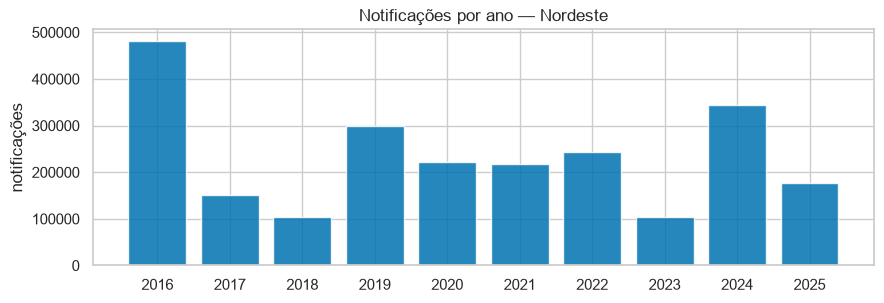

In [2]:
build_region_parquet(REGION_SPEC, DEFAULT_YEARS)
manifest = json.loads(region_manifest_path(REGION).read_text(encoding="utf-8"))
pop = pd.read_parquet(ROOT / f"data/ml/{REGION}/populacao.parquet")

by_year = pd.Series(manifest["registros_por_ano"], name="notificações").astype(int)
by_year.index = by_year.index.astype(int)
display(by_year.to_frame())

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(by_year.index.astype(str), by_year.values, color=ACCENT, alpha=0.85)
ax.set_title(f"Notificações por ano — {REGION_SPEC.name}")
ax.set_ylabel("notificações")
plt.tight_layout()

panel_probe = build_features_panel(REGION, ANO_FOCO, "v0")
print(
    f"\n{ANO_FOCO}: {by_year.get(ANO_FOCO, '?')} notificações | "
    f"{panel_probe[Col.ID_MUNICIP].nunique()} municípios elegíveis (≥{DEFAULT_MIN_CASOS_ANUAL} casos/ano) | "
    f"{len(panel_probe):,} linhas município×semana"
)
print(f"UFs: {', '.join(REGION_SPEC.ufs)}")
print(f"População: referência IBGE {REFERENCE_POP_YEAR}")


---

## 3. Baseline v0 — casos absolutos

Primeiro passo: clusterizar só **casos da semana**. Funciona tecnicamente, mas favorece municípios populosos. Silhouette alta aqui é armadilha: em 1D o cluster vira quase ordenação por volume.

In [3]:
def run_version(version: str, k: int = K_FINAL):
    panel = build_features_panel(REGION, ANO_FOCO, version)
    result = run_kmeans(panel, version, k=k)
    return {"version": version, "panel": panel, "result": result}

res_v0 = run_version("v0")
sizes_v0 = pd.Series(res_v0["result"].labels).value_counts().sort_index()
pct_base = 100 * sizes_v0.get(0, 0) / len(res_v0["panel"])

print(f"silhouette v0: {res_v0['result'].metrics['silhouette']:.3f}")
print(f"Cluster 0 concentra {pct_base:.1f}% das linhas município×semana")
display(res_v0["result"].cluster_means.round(2))
display(sizes_v0.rename("linhas"))

silhouette v0: 0.943
Cluster 0 concentra 98.1% das linhas município×semana


,casos
cluster,
0,3.98
1,160.89
2,600.09
3,2539.54


0    38961
1      686
2       70
3       11
Name: linhas, dtype: int64

---

## 4. Escada v0→v4 (+1 feature por versão)

Cada versão **adiciona** uma feature (cumulativo). Usamos K=4 provisório para comparar versões entre si.


,versão,bloco,silhouette,davies_bouldin,n_feat,Δ silhouette
0,v0,baseline: casos,0.9430,0.4568,1,NaN
1,v1,+ incidência por 100 mil,0.8959,0.6299,2,-0.0470
2,v2,+ média móvel (3 semanas),0.8880,0.5948,3,-0.0079
3,v3,+ crescimento semanal,0.8728,0.9069,4,-0.0152
4,v4,+ aceleração,0.8797,0.8795,5,0.0069


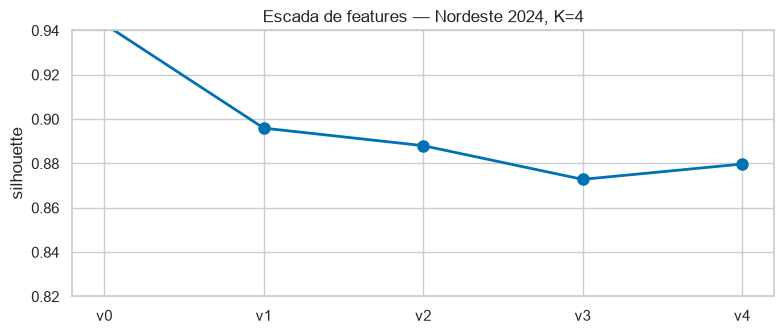

In [4]:
runs_ladder = [run_version(v) for v in VERSIONS]
runs_by = {r["version"]: r for r in runs_ladder}

evo = pd.DataFrame([{
    "versão": r["version"],
    "bloco": VERSION_BLOCKS[r["version"]],
    "silhouette": r["result"].metrics["silhouette"],
    "davies_bouldin": r["result"].metrics["davies_bouldin"],
    "n_feat": len(FEATURE_SETS[r["version"]]),
} for r in runs_ladder])
evo["Δ silhouette"] = evo["silhouette"].diff().round(4)
display(evo.round(4))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(evo["versão"], evo["silhouette"], "o-", color=ACCENT, lw=2, markersize=8)
ax.set_ylim(0.82, 0.94)
ax.set_ylabel("silhouette")
ax.set_title(f"Escada de features — {REGION_SPEC.name} {ANO_FOCO}, K={K_FINAL}")
plt.tight_layout()


### 4.1 v1 — incidência compara municípios

No Nordeste agregado, **v1 ≠ v0**: dois municípios com casos parecidos podem ter incidências distintas.


In [5]:
panel_v1 = runs_by["v1"]["panel"]
sem_pico = panel_v1.groupby(Col.SEM_NOT)[Feat.CASOS].sum().idxmax()
snap = panel_v1[panel_v1[Col.SEM_NOT] == sem_pico].nlargest(8, Feat.CASOS)
snap = snap.merge(pop[["id_municip", "municipio"]], left_on=Col.ID_MUNICIP, right_on="id_municip")
display(snap[["municipio", Feat.CASOS, Feat.INCIDENCIA_100K]].round(2))

,municipio,casos,incidencia_100k
0,Vitória da Conquista,3029,768.73
1,Caetité,1218,2231.91
2,Barra do Choça,1130,2936.51
3,Feira de Santana,635,96.51
4,Santo Antônio de Jesus,566,518.00
5,Salvador,483,18.80
6,Guanambi,478,513.62
7,Natal,415,52.84


### 4.2 v4 — dinâmica temporal (crescimento e aceleração)

,casos,incidencia_100k,media_movel_3,crescimento,aceleracao
cluster,,,,,
0,5.15,12.71,13.12,-0.03,1.13
1,55.69,265.82,344.55,-174.19,-286.37
2,95.74,443.04,350.87,159.67,201.59
3,1836.81,1216.17,1155.96,20.95,-117.78


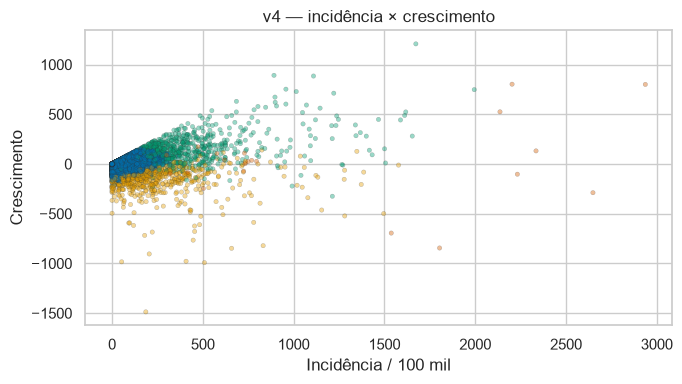

In [6]:
res_v4 = runs_by["v4"]["result"]
labeled_v4 = runs_by["v4"]["panel"].assign(cluster=res_v4.labels)
display(res_v4.cluster_means.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
colors = labeled_v4["cluster"].map({i: PALETTE[i] for i in range(K_FINAL)})
ax.scatter(labeled_v4[Feat.INCIDENCIA_100K], labeled_v4[Feat.CRESCIMENTO], c=colors, **SCATTER_KW)
ax.set_xlabel("Incidência / 100 mil")
ax.set_ylabel("Crescimento")
ax.set_title("v4 — incidência × crescimento")
plt.tight_layout()

---

## 5. Escolha de K (modelo final v4)

Com a escada fechada, calibramos **K** no conjunto de features v4. Métricas internas sozinhas empurram K alto; buscamos equilíbrio com interpretabilidade (referência: cotovelo no Nordeste → K=4).


,K,silhouette,davies_bouldin,inertia,menor_cluster
0,2,0.9035,0.9838,145241.1179,673
1,3,0.8859,1.0216,117777.8941,565
2,4,0.8797,0.8795,95446.8378,21
3,5,0.8470,0.8793,82875.5094,11
4,6,0.8421,0.8882,73025.9612,11
5,7,0.7943,0.9318,65662.6926,11
6,8,0.7892,0.9598,59160.2835,11


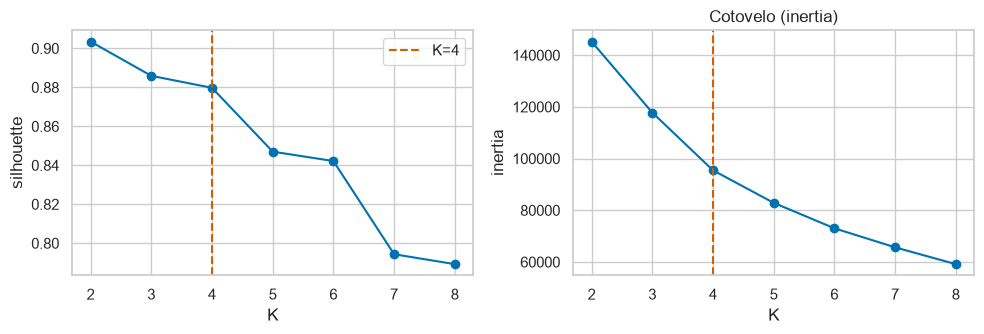

In [7]:
panel_final = build_features_panel(REGION, ANO_FOCO, VERSION_FINAL)

k_rows = []
for k in K_RANGE:
    r = run_kmeans(panel_final, VERSION_FINAL, k=k)
    sizes = pd.Series(r.labels).value_counts()
    k_rows.append({
        "K": k,
        "silhouette": r.metrics["silhouette"],
        "davies_bouldin": r.metrics["davies_bouldin"],
        "inertia": r.metrics["inertia"],
        "menor_cluster": int(sizes.min()),
    })

k_df = pd.DataFrame(k_rows)
display(k_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(k_df["K"], k_df["silhouette"], "o-", color=ACCENT)
axes[0].axvline(K_FINAL, color="#D55E00", ls="--", label=f"K={K_FINAL}")
axes[0].set_xlabel("K")
axes[0].set_ylabel("silhouette")
axes[0].legend()

axes[1].plot(k_df["K"], k_df["inertia"], "o-", color=ACCENT)
axes[1].axvline(K_FINAL, color="#D55E00", ls="--")
axes[1].set_xlabel("K")
axes[1].set_ylabel("inertia")
axes[1].set_title("Cotovelo (inertia)")
plt.tight_layout()


---

## 6. Perfis dos clusters (v4, K=4)

Nomes abaixo são **interpretação pós-cluster**, não rótulos oficiais de vigilância.


,casos,incidencia_100k,media_movel_3,crescimento,aceleracao,leitura
cluster,,,,,,
0,5.15,12.71,13.12,-0.03,1.13,baixa incidência
1,55.69,265.82,344.55,-174.19,-286.37,incidência moderada em queda
2,95.74,443.04,350.87,159.67,201.59,alta incidência em crescimento
3,1836.81,1216.17,1155.96,20.95,-117.78,incidência moderada/alta estável


cluster
0    38411
1      620
2      676
3       21
Name: linhas, dtype: int64

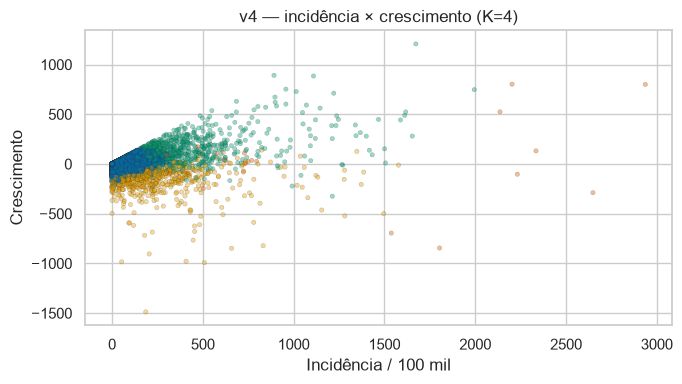

In [8]:
res_final = run_kmeans(panel_final, VERSION_FINAL, k=K_FINAL)
labeled = panel_final.assign(cluster=res_final.labels)
means = res_final.cluster_means.round(2)

NOMES = {}
for c in means.index:
    row = means.loc[c]
    if row[Feat.CRESCIMENTO] > 50:
        nome = "alta incidência em crescimento"
    elif row[Feat.CRESCIMENTO] < -50:
        nome = "incidência moderada em queda"
    elif row[Feat.INCIDENCIA_100K] >= means[Feat.INCIDENCIA_100K].median():
        nome = "incidência moderada/alta estável"
    else:
        nome = "baixa incidência"
    NOMES[int(c)] = nome

perfis = means.copy()
perfis["leitura"] = perfis.index.map(NOMES)
display(perfis)

sizes = labeled["cluster"].value_counts().sort_index()
display(sizes.rename("linhas"))

fig, ax = plt.subplots(figsize=(7, 4))
colors = labeled["cluster"].map({i: PALETTE[i] for i in range(K_FINAL)})
ax.scatter(labeled[Feat.INCIDENCIA_100K], labeled[Feat.CRESCIMENTO], c=colors, **SCATTER_KW)
ax.set_xlabel("Incidência / 100 mil")
ax.set_ylabel("Crescimento")
ax.set_title(f"v4 — incidência × crescimento (K={K_FINAL})")
plt.tight_layout()


---

## 7. Transições semana t→t+1

Como cada município muda de perfil entre semanas consecutivas. Análise **posterior** ao clustering (não treina o modelo).

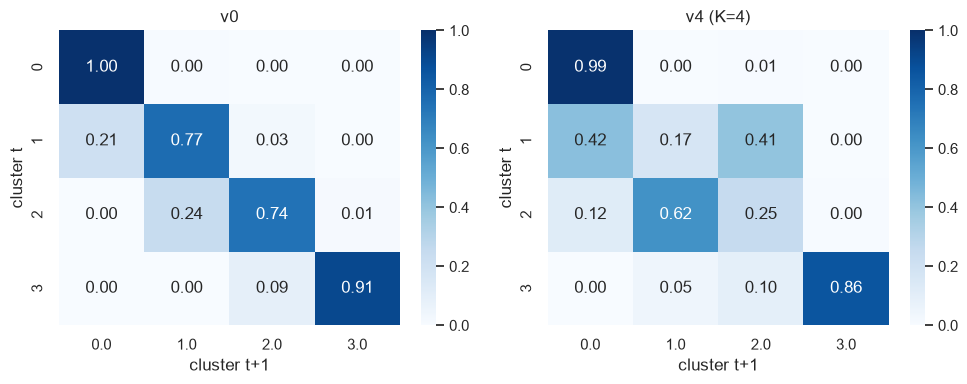

In [9]:
trans_v0 = transition_matrix(runs_by["v0"]["panel"], runs_by["v0"]["result"].labels)
trans_final = transition_matrix(panel_final, res_final.labels)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, trans, title in [(axes[0], trans_v0, "v0"), (axes[1], trans_final, f"v4 (K={K_FINAL})")]:
    sns.heatmap(trans, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
    ax.set_xlabel("cluster t+1")
    ax.set_ylabel("cluster t")
    ax.set_title(title)
plt.tight_layout()


### Diagrama de estados (FSM): v4, K=4

Desenhado com **Graphviz** (`circo`), não matplotlib.

- só o modelo **v4**
- **nenhuma transição cortada** (inclui todas as arestas com probabilidade > 0)
- self-loops no lado externo de cada nó
- ida e volta em arestas separadas


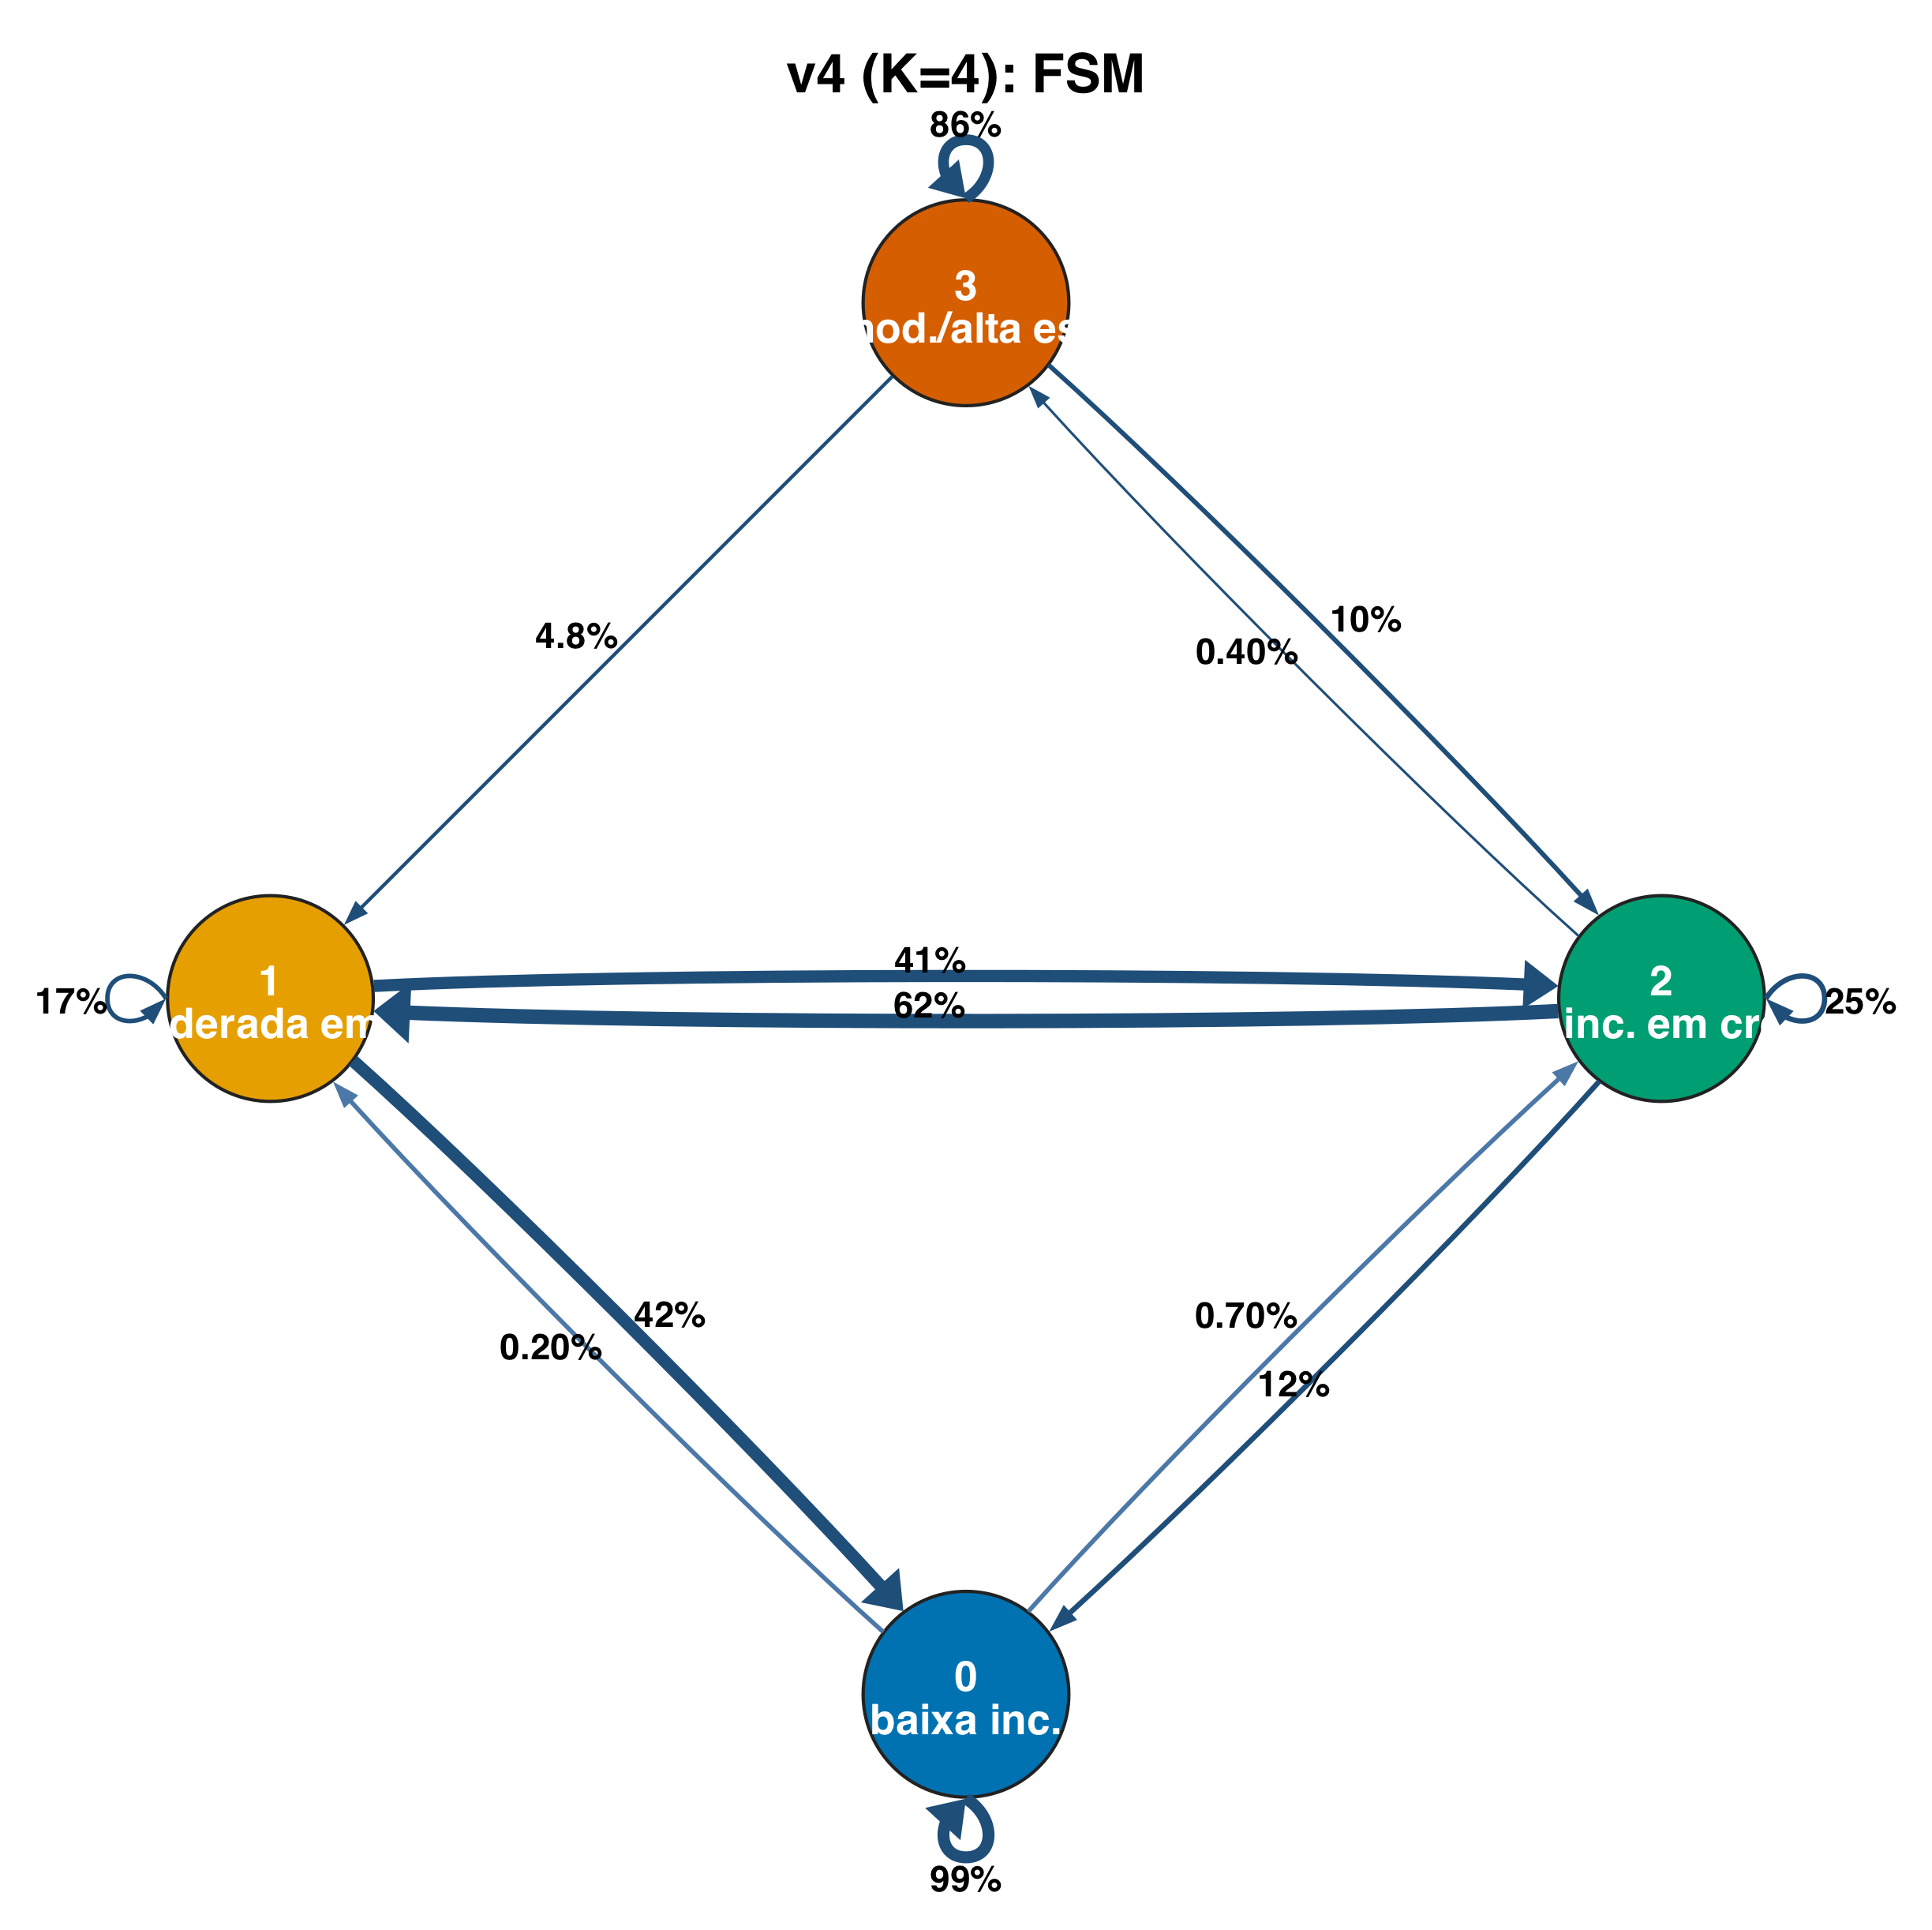

/Users/antonielmagalhaes/d/acad/ia-final/ia-iv/data/cache/fsm_v4_graphviz.png


In [10]:
import graphviz
from IPython.display import Image, display

LOOP_PORT = {0: "s", 1: "w", 2: "e", 3: "n"}  # sul / oeste / leste / norte


def _fmt_prob(p: float) -> str:
    if p >= 0.05:
        return f"{p:.0%}"
    if p >= 0.01:
        return f"{p:.1%}"
    return f"{p:.2%}"


def plot_transition_fsm_graphviz(
    trans,
    *,
    state_labels: dict[int, str],
    palette: list[str],
    title: str = "v4 (K=4): FSM",
    out_path: Path | None = None,
    display_width: int = 1200,
) -> Path:
    """FSM Graphviz em alta resolução, texto grande, pouco padding."""
    g = graphviz.Digraph("fsm_v4", format="png", engine="circo")
    g.attr(
        size="8,8!",
        dpi="300",
        pad="0.15",
        margin="0.08",
        bgcolor="white",
        overlap="false",
        splines="true",
        sep="+18,18",
        nodesep="0.55",
        mindist="1.15",
        label=title,
        labelloc="t",
        fontsize="36",
        fontname="Helvetica-Bold",
    )
    g.attr(
        "node",
        shape="circle",
        style="filled",
        fontname="Helvetica-Bold",
        fontsize="28",
        fontcolor="white",
        width="1.9",
        height="1.9",
        fixedsize="true",
        penwidth="2.2",
    )
    g.attr(
        "edge",
        fontname="Helvetica-Bold",
        fontsize="24",
        color="#1f4e79",
        labelfontcolor="#111111",
        arrowsize="1.2",
        penwidth="2.0",
    )

    n = len(trans)
    for i in range(n):
        short = (
            str(state_labels.get(i, i))
            .replace("crescimento", "cresc.")
            .replace("incidência", "inc.")
            .replace("moderada/alta estável", "mod./alta estável")
            .replace("alta incidência em crescimento", "alta em cresc.")
            .replace("incidência moderada em queda", "mod. em queda")
            .replace("baixa incidência", "baixa")
        )
        g.node(
            str(i),
            label=f"{i}\\n{short}",
            fillcolor=palette[i % len(palette)],
            color="#222222",
        )

    for i in range(n):
        p = float(trans.fillna(0).loc[i, i]) if i in trans.index and i in trans.columns else 0.0
        if p <= 0:
            continue
        port = LOOP_PORT.get(i, "e")
        g.edge(
            f"{i}:{port}",
            f"{i}:{port}",
            label=_fmt_prob(p),
            penwidth=str(2.0 + 6.0 * p),
            color="#1f4e79",
            fontsize="24",
            fontname="Helvetica-Bold",
        )

    for src in range(n):
        for dst in range(n):
            if src == dst:
                continue
            if src not in trans.index or dst not in trans.columns:
                continue
            p = float(trans.fillna(0).loc[src, dst])
            if p <= 0:
                continue
            if src == 0 and p < 0.05:
                pw, color = 3.0, "#4C78A8"
            else:
                pw, color = 1.6 + 8.0 * min(p / 0.5, 1.0), "#1f4e79"
            g.edge(
                str(src),
                str(dst),
                label=_fmt_prob(p),
                penwidth=str(pw),
                color=color,
                fontsize="24",
                fontname="Helvetica-Bold",
            )

    out = out_path or (ROOT / "data" / "cache" / "fsm_v4_graphviz")
    out.parent.mkdir(parents=True, exist_ok=True)
    rendered = Path(g.render(str(out), cleanup=True))
    return rendered


STATE_ORDER = list(range(K_FINAL))
trans_final_ord = trans_final.reindex(index=STATE_ORDER, columns=STATE_ORDER)
labels_final = {i: NOMES[i] for i in range(K_FINAL)}
fsm_png = plot_transition_fsm_graphviz(
    trans_final_ord,
    state_labels=labels_final,
    palette=PALETTE[:K_FINAL],
    title=f"v4 (K={K_FINAL}): FSM",
    display_width=1200,
)
display(Image(filename=str(fsm_png), width=1200))
print(fsm_png)


---

## 8. Estabilidade em 10 anos (v0 vs v4)

A escada se comporta de forma parecida ao longo do tempo? Comparamos silhouette de v0 e v4 em cada ano (K=4).


,ano,v0,v4,Δ (v4−v0)
0,2016,0.9393,0.9299,-0.0093
1,2017,0.9258,0.9161,-0.0097
2,2018,0.8747,0.9077,0.0329
3,2019,0.9144,0.8435,-0.0709
4,2020,0.8938,0.8546,-0.0392
5,2021,0.9360,0.8540,-0.0820
6,2022,0.9247,0.8721,-0.0526
7,2023,0.9047,0.8515,-0.0532
8,2024,0.9430,0.8797,-0.0632
9,2025,0.9472,0.9573,0.0100


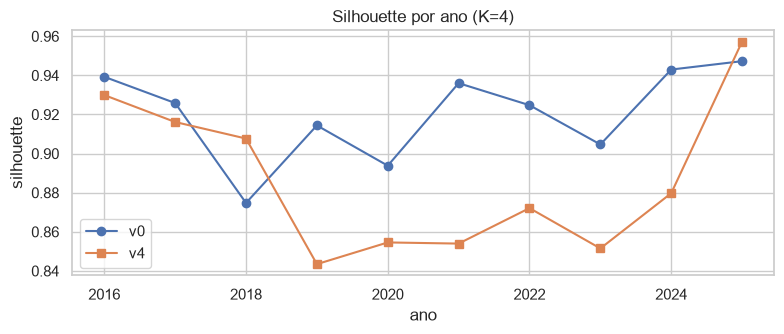

In [11]:
def silhouette_ano(year: int, version: str) -> float:
    panel = build_features_panel(REGION, year, version)
    return float(run_kmeans(panel, version, k=K_FINAL).metrics["silhouette"])

estab = pd.DataFrame({
    "ano": DEFAULT_YEARS,
    "v0": [silhouette_ano(y, "v0") for y in DEFAULT_YEARS],
    "v4": [silhouette_ano(y, VERSION_FINAL) for y in DEFAULT_YEARS],
})
estab["Δ (v4−v0)"] = estab["v4"] - estab["v0"]
display(estab.round(4))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(estab["ano"], estab["v0"], "o-", label="v0")
ax.plot(estab["ano"], estab["v4"], "s-", label="v4")
ax.set_xlabel("ano")
ax.set_ylabel("silhouette")
ax.set_title(f"Silhouette por ano (K={K_FINAL})")
ax.legend()
plt.tight_layout()


---

## 9. Log de experimentos e limitações

**Limitações:** população fixa (IBGE 2024); clustering semanal independente; subnotificação; sem clima defasado ainda; validação causal não feita.

**Conclusão:** a história não é prever surto, é transformar séries semanais em **estágios interpretáveis** e observar **transições**. v0 mostra o limite de casos brutos; v1 a v4 trazem dinâmica temporal (incidência, média móvel, crescimento e aceleração); K=4 equilibra métrica e leitura.


In [12]:
exp_df = pd.json_normalize(load_experiments())
if "config.region" in exp_df.columns:
    mask = (exp_df["config.region"] == REGION) & (exp_df["config.year"] == ANO_FOCO)
    cols = [c for c in ["id", "tag", "config.feature_version", "metrics.silhouette", "config.k"] if c in exp_df.columns]
    display(exp_df[mask].sort_values("id")[cols].tail(8).round(4))
else:
    print("Log experiments.jsonl disponível via: uv run ia-iv-exp list")

,id,tag,config.feature_version,metrics.silhouette,config.k
